In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
plt.style.use("ggplot")

In [102]:
df = pd.read_csv("../01Dataset/bank.csv")

In [103]:
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [104]:
df.tail

<bound method NDFrame.tail of        age          job  marital  education default  balance housing loan  \
0       59       admin.  married  secondary      no     2343     yes   no   
1       56       admin.  married  secondary      no       45      no   no   
2       41   technician  married  secondary      no     1270     yes   no   
3       55     services  married  secondary      no     2476     yes   no   
4       54       admin.  married   tertiary      no      184      no   no   
...    ...          ...      ...        ...     ...      ...     ...  ...   
11157   33  blue-collar   single    primary      no        1     yes   no   
11158   39     services  married  secondary      no      733      no   no   
11159   32   technician   single  secondary      no       29      no   no   
11160   43   technician  married  secondary      no        0      no  yes   
11161   34   technician  married  secondary      no        0      no   no   

        contact  day month  duration  campaig

In [105]:
df.sample(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
7826,41,services,married,secondary,no,804,yes,no,unknown,20,may,127,8,-1,0,unknown,no
4281,55,technician,divorced,tertiary,no,0,no,no,cellular,18,aug,237,1,-1,0,unknown,yes
8672,41,technician,married,secondary,no,128,yes,no,cellular,27,aug,100,2,-1,0,unknown,no
10188,54,retired,divorced,secondary,no,2761,no,no,cellular,16,jul,771,1,-1,0,unknown,no
6140,78,retired,divorced,secondary,no,631,no,no,telephone,11,aug,95,1,-1,0,unknown,no


In [106]:
df.shape

(11162, 17)

In [107]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [109]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [110]:
df.duplicated().sum()

np.int64(0)

In [111]:
df.describe()


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [112]:
df['deposit'].unique()

array(['yes', 'no'], dtype=object)

In [113]:
df['deposit'].value_counts()

deposit
no     5873
yes    5289
Name: count, dtype: int64

In [114]:
(df['deposit'].value_counts(normalize=True) * 100).round(2)

deposit
no     52.62
yes    47.38
Name: proportion, dtype: float64

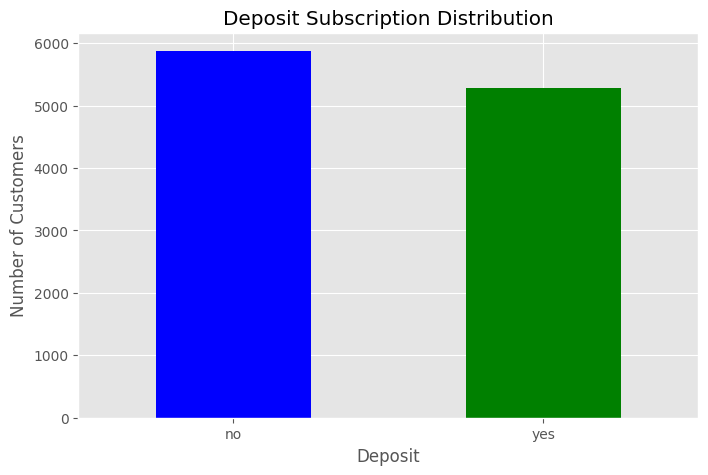

<Figure size 640x480 with 0 Axes>

In [115]:
df['deposit'].value_counts().plot(kind='bar', color=['blue', 'green'], figsize=(8, 5))
plt.xlabel('Deposit')
plt.ylabel('Number of Customers')
plt.title('Deposit Subscription Distribution')
plt.xticks(rotation=0)
plt.show()
plt.savefig("../03Images/deposit_distribution.png",
            bbox_inches="tight",
            dpi=300)

In [116]:
df['deposit'].value_counts()

deposit
no     5873
yes    5289
Name: count, dtype: int64

In [117]:
df['converted'] = df['deposit'].map({'yes': 1, 'no': 0})    

In [118]:
df[['deposit', 'converted']].sample(10)

,deposit,converted
7879,no,0
4764,yes,1
413,yes,1
1473,yes,1
8941,no,0
11134,no,0
6007,no,0
729,yes,1
7904,no,0
9687,no,0


In [119]:
total_customers = len(df)
converted = df['converted'].sum()
not_converted = total_customers - converted
conversion_rate = (converted / total_customers) * 100
print("Total Customers:", total_customers)
print("Converted Customers:", converted)
print("Not Converted Customers:", not_converted)
print(f"Conversion Rate: {conversion_rate:.2f}%")

Total Customers: 11162
Converted Customers: 5289
Not Converted Customers: 5873
Conversion Rate: 47.38%


In [120]:
kpi_df = pd.DataFrame({'Metric': ['Total Customers', 'Converted Customers', 'Not Converted Customers', 'Conversion Rate'],
                          'Value': [total_customers, converted, not_converted, round(conversion_rate,2)]})
kpi_df

,Metric,Value
0,Total Customers,11162.00
1,Converted Customers,5289.00
2,Not Converted Customers,5873.00
3,Conversion Rate,47.38


In [121]:
kpi_df.to_csv("../01Dataset/kpi_metrics.csv", index=False)  

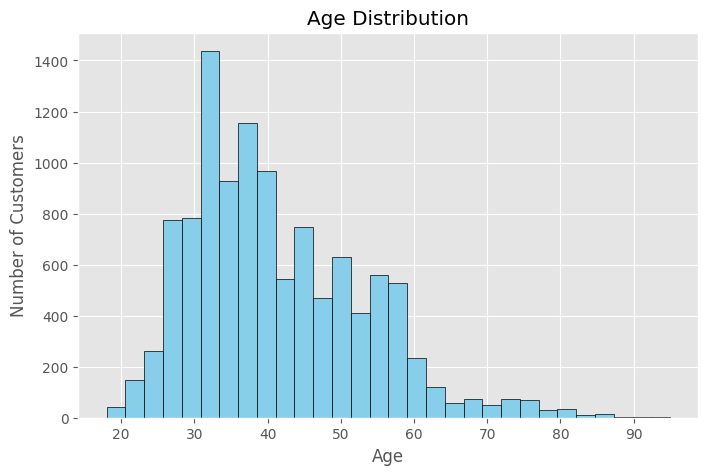

In [122]:
plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.title('Age Distribution')
plt.savefig("../03Images/age_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

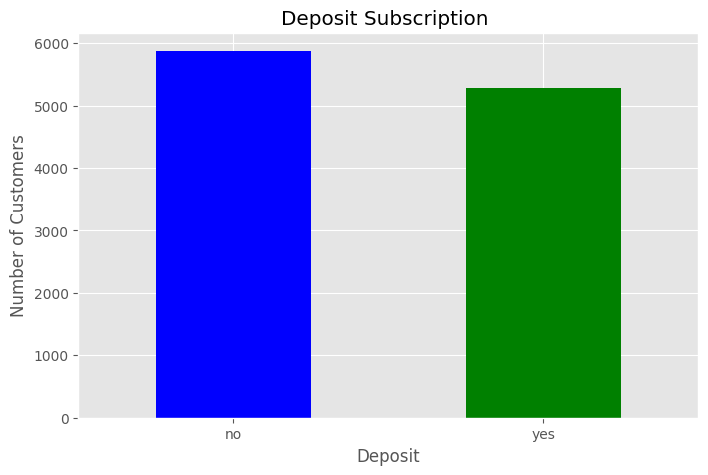

In [123]:
plt.figure(figsize=(8, 5))
df['deposit'].value_counts().plot(kind='bar', color=['blue', 'green'])
plt.xlabel('Deposit')
plt.ylabel('Number of Customers')
plt.title('Deposit Subscription ')
plt.xticks(rotation=0)
plt.savefig("../03Images/deposit_subscription.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

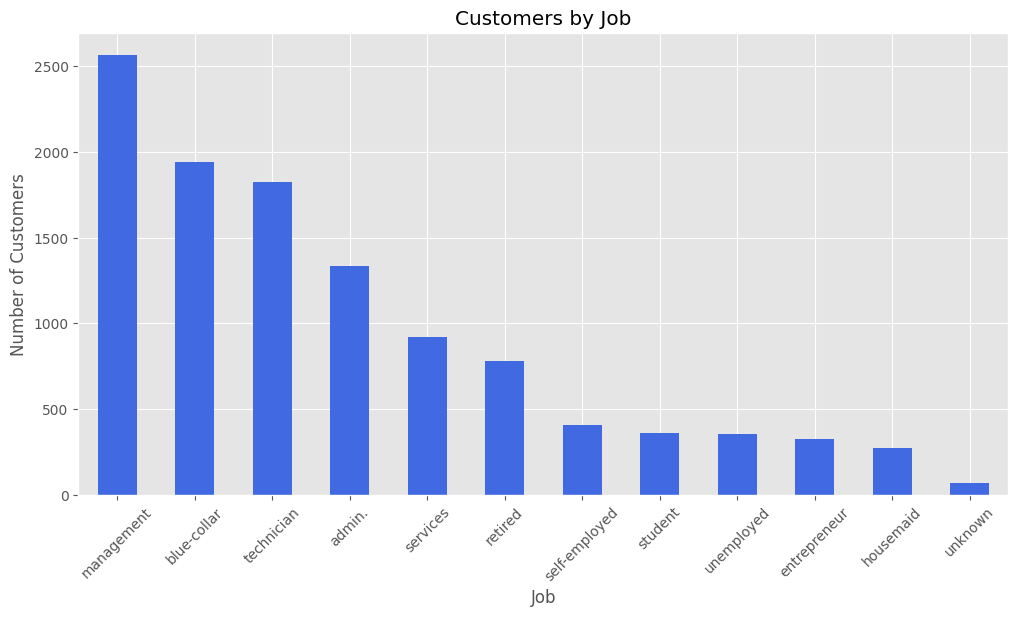

In [124]:
plt.figure(figsize=(12, 6))
df['job'].value_counts().plot(kind='bar', color='royalblue')
plt.xlabel('Job')
plt.ylabel('Number of Customers')
plt.title('Customers by Job')
plt.xticks(rotation=45)
plt.savefig("../03Images/job_distribution.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

In [125]:
job_conversion = (df.groupby('job')['converted'].mean().sort_values(ascending=False)*100)
job_conversion

job
student          74.722222
retired          66.323907
unemployed       56.582633
management       50.701481
unknown          48.571429
admin.           47.301349
self-employed    46.172840
technician       46.077894
services         39.978332
housemaid        39.781022
entrepreneur     37.500000
blue-collar      36.419753
Name: converted, dtype: float64

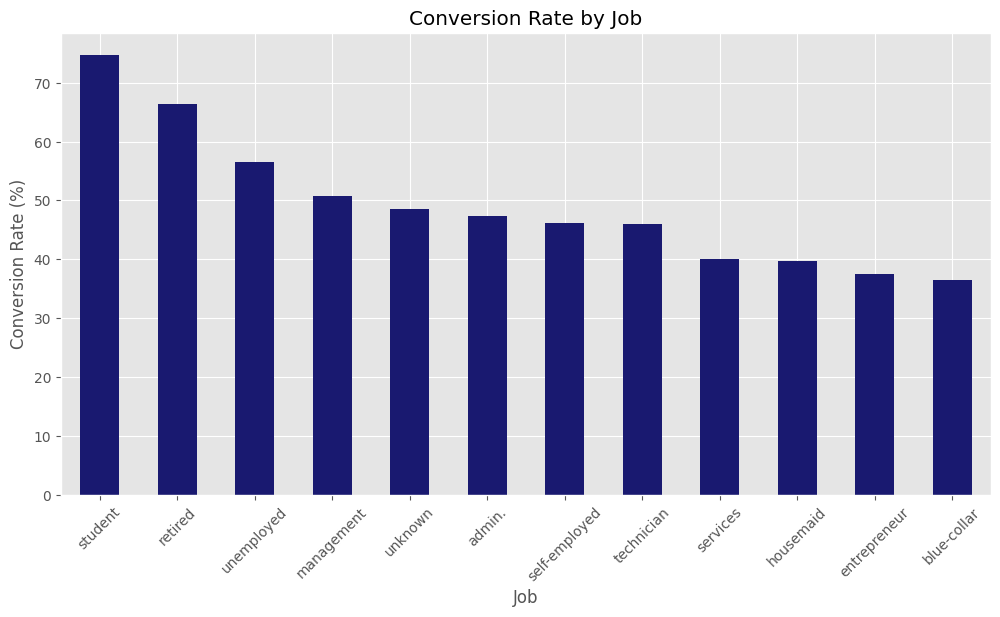

In [126]:
plt.figure(figsize=(12, 6))
job_conversion.plot(kind='bar', color='midnightblue')
plt.xlabel('Job')   
plt.ylabel('Conversion Rate (%)')
plt.title('Conversion Rate by Job')
plt.xticks(rotation=45)
plt.savefig("../03Images/job_conversion_rate.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [127]:
marital_conversion = (df.groupby('marital')['converted'].mean().sort_values(ascending=False)*100)
marital_conversion

marital
single      54.349062
divorced    48.105182
married     43.378995
Name: converted, dtype: float64

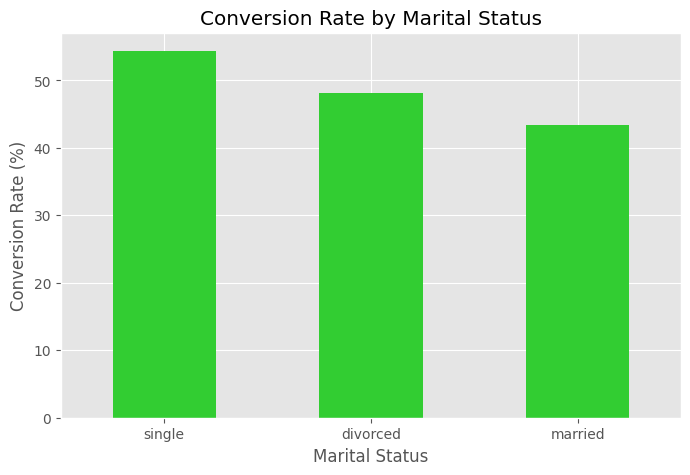

In [128]:
plt.figure(figsize=(8, 5))
marital_conversion.plot(kind='bar', color='limegreen')
plt.xlabel('Marital Status')    
plt.ylabel('Conversion Rate (%)')
plt.title('Conversion Rate by Marital Status')
plt.xticks(rotation=0)
plt.savefig("../03Images/marital_conversion_rate.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [129]:
education_conversion = (df.groupby('education')['converted'].mean().sort_values(ascending=False)*100)
education_conversion

education
tertiary     54.106804
unknown      50.704225
secondary    44.740687
primary      39.400000
Name: converted, dtype: float64

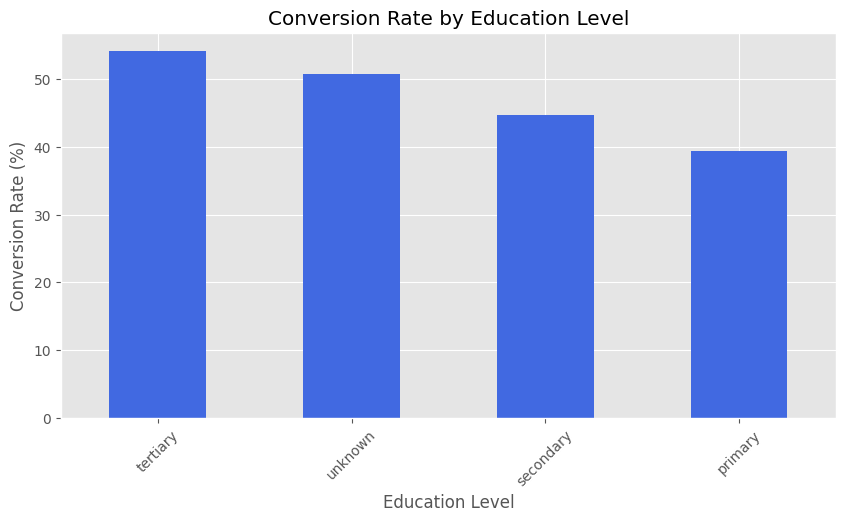

In [130]:
plt.figure(figsize=(10, 5))
education_conversion.plot(kind='bar', color='royalblue')
plt.xlabel('Education Level')
plt.ylabel('Conversion Rate (%)')
plt.title('Conversion Rate by Education Level')
plt.xticks(rotation=45)
plt.savefig("../03Images/education_conversion_rate.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [131]:
housing_conversion = (df.groupby('housing')['converted'].mean().sort_values(ascending=False)*100)
housing_conversion   


housing
no     57.031117
yes    36.640788
Name: converted, dtype: float64

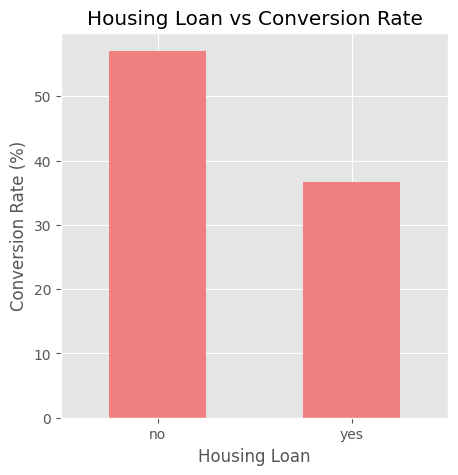

In [132]:
plt.figure(figsize=(5, 5))
housing_conversion.plot(kind='bar', color='lightcoral')
plt.xlabel('Housing Loan')
plt.ylabel('Conversion Rate (%)')
plt.title('Housing Loan vs Conversion Rate')
plt.xticks(rotation=0)
plt.savefig("../03Images/housing_conversion_rate.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [133]:
loan_conversion = (df.groupby('loan')['converted'].mean().sort_values(ascending=False)*100)
loan_conversion

loan
no     49.525871
yes    33.150685
Name: converted, dtype: float64

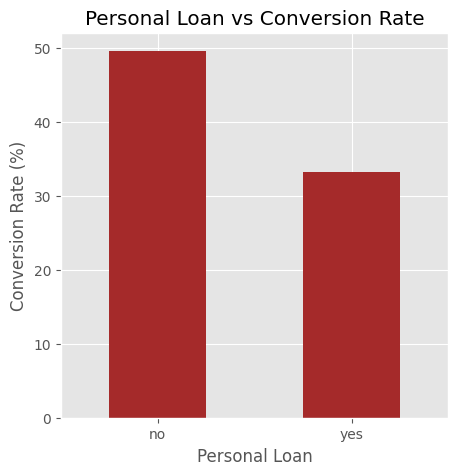

In [134]:
plt.figure(figsize=(5, 5))
loan_conversion.plot(kind='bar', color='brown')
plt.xlabel('Personal Loan')
plt.ylabel('Conversion Rate (%)')
plt.title('Personal Loan vs Conversion Rate')
plt.xticks(rotation=0)
plt.savefig("../03Images/personal_loan_conversion_rate.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [135]:
contact_conversion = (df.groupby('contact')['converted'].mean().sort_values(ascending=False)*100)
contact_conversion

contact
cellular     54.327282
telephone    50.387597
unknown      22.591645
Name: converted, dtype: float64

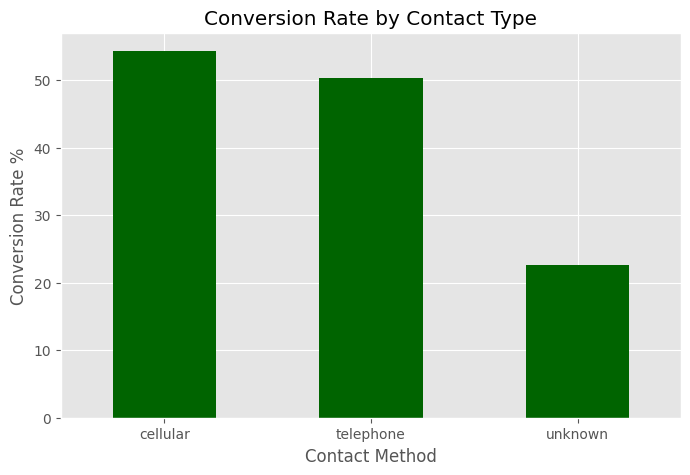

In [136]:
plt.figure(figsize=(8, 5))
contact_conversion.plot(kind='bar', color='darkgreen')
plt.xlabel('Contact Method')
plt.ylabel('Conversion Rate %')
plt.xticks(rotation=0)
plt.title('Conversion Rate by Contact Type')
plt.savefig("../03Images/contact_conversion_rate.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [137]:
month_conversion = (df.groupby('month')['converted'].mean()*100)
month_conversion

month
apr    62.513543
aug    45.292956
dec    90.909091
feb    56.829897
jan    41.279070
jul    41.413474
jun    44.680851
mar    89.855072
may    32.754958
nov    42.735949
oct    82.397959
sep    84.326019
Name: converted, dtype: float64

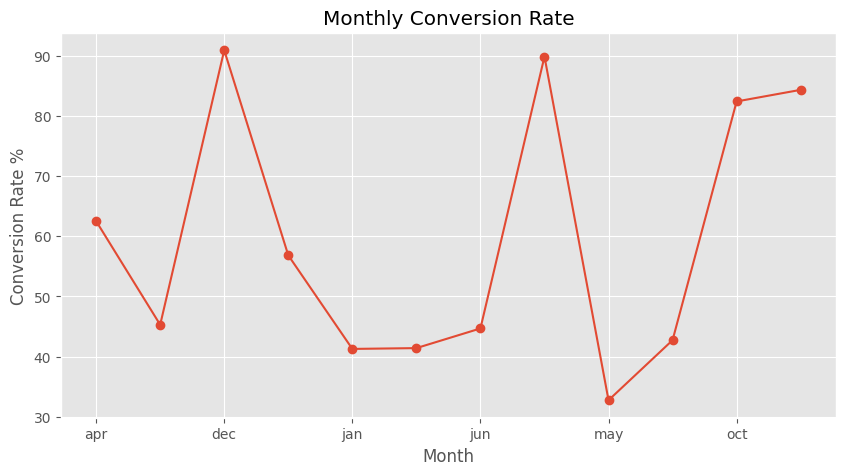

In [138]:
plt.figure(figsize=(10, 5))
month_conversion.plot(kind='line', marker='o')
plt.title("Monthly Conversion Rate")
plt.xlabel("Month")
plt.ylabel("Conversion Rate %")
plt.grid(True)
plt.savefig("../03Images/monthly_conversion_rate.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [139]:
campaign_conversion = (df.groupby('campaign')['converted'].mean()*100)
campaign_conversion.head(15)

campaign
1     53.376407
2     46.268164
3     46.782740
4     41.115435
5     36.772487
6     34.716981
7     33.812950
8     25.000000
9     29.166667
10    26.923077
11    40.000000
12    13.793103
13    20.000000
14    26.666667
15    30.769231
Name: converted, dtype: float64

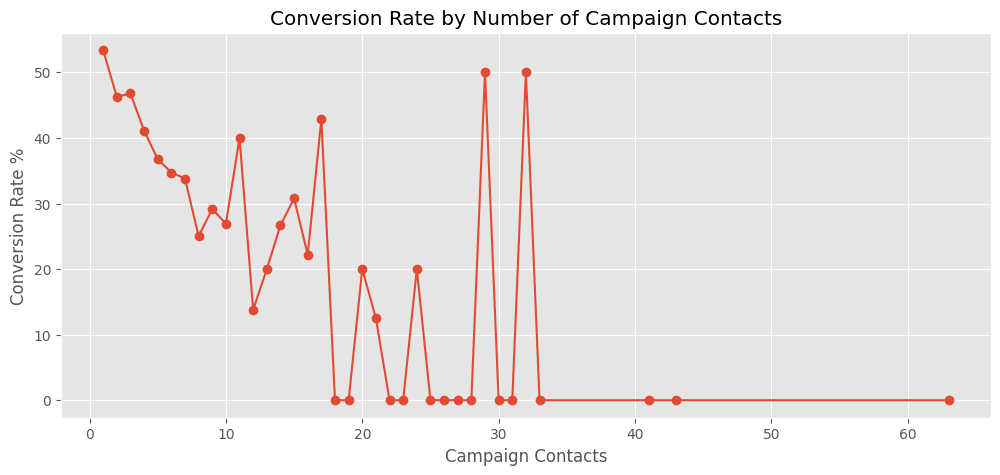

In [140]:
plt.figure(figsize=(12, 5))
campaign_conversion.plot(kind='line', marker='o')
plt.title("Conversion Rate by Number of Campaign Contacts")
plt.xlabel("Campaign Contacts")
plt.ylabel("Conversion Rate %")
plt.grid(True)
plt.savefig("../03Images/campaign_contacts_conversion_rate.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

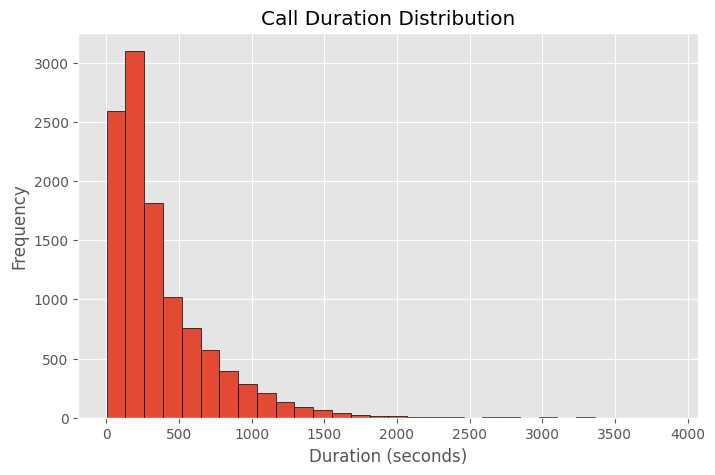

In [141]:
plt.figure(figsize=(8, 5))
plt.hist(df['duration'], bins=30, edgecolor='black')
plt.title("Call Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")
plt.savefig("../03Images/call_duration_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

<Figure size 700x500 with 0 Axes>

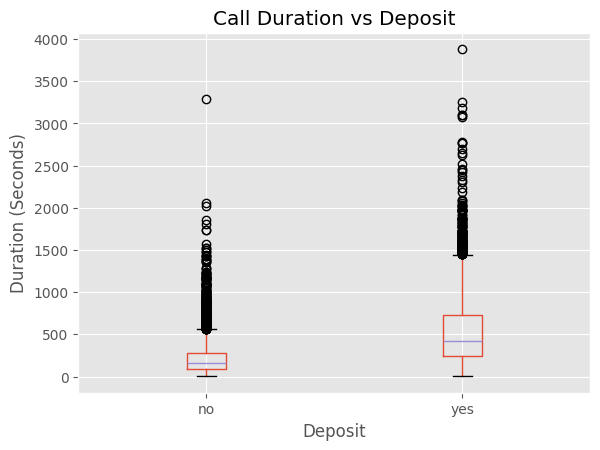

In [142]:
plt.figure(figsize=(7, 5))
df.boxplot(
    column='duration',
    by='deposit'
)
plt.title("Call Duration vs Deposit")
plt.suptitle("")
plt.xlabel("Deposit")
plt.ylabel("Duration (Seconds)")
plt.savefig("../03Images/call_duration_vs_deposit.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

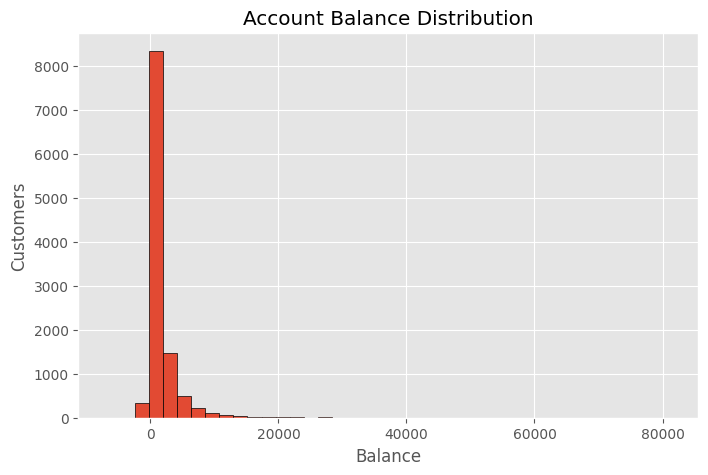

In [143]:
plt.figure(figsize=(8, 5))
plt.hist(df['balance'], bins=40, edgecolor='black')
plt.title("Account Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Customers")
plt.savefig("../03Images/account_balance_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [144]:
balance_conversion = (df.groupby('deposit')['balance'].mean())
balance_conversion

deposit
no     1280.227141
yes    1804.267915
Name: balance, dtype: float64

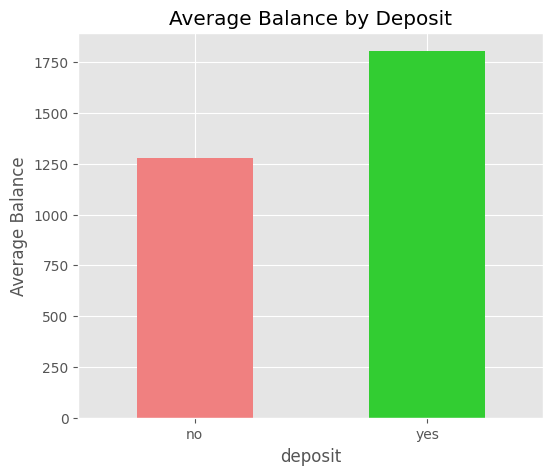

In [145]:
plt.figure(figsize=(6, 5))
balance_conversion.plot(kind='bar', color=['lightcoral', 'limegreen'])
plt.title("Average Balance by Deposit")
plt.ylabel("Average Balance")
plt.xticks(rotation=0)
plt.savefig("../03Images/average_balance_by_deposit.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [146]:
poutcome_conversion = (df.groupby('poutcome')['converted'].mean()*100)
poutcome_conversion

poutcome
failure    50.325733
other      57.169460
success    91.316527
unknown    40.667788
Name: converted, dtype: float64

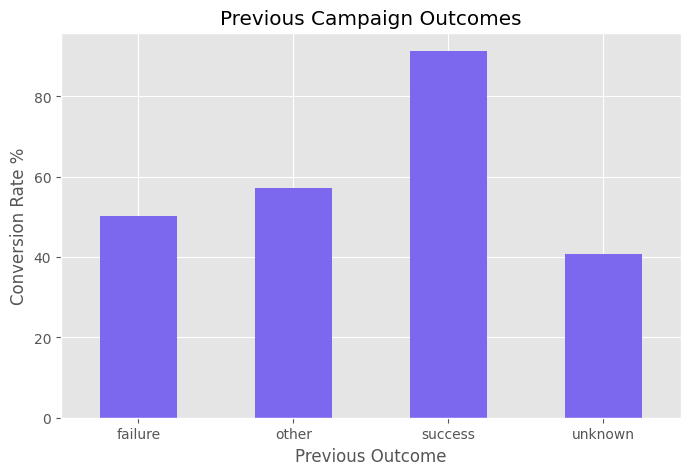

In [147]:
plt.figure(figsize=(8, 5))
poutcome_conversion.plot(kind='bar', color='mediumslateblue')
plt.title("Previous Campaign Outcomes")
plt.xlabel("Previous Outcome")
plt.ylabel("Conversion Rate %")
plt.xticks(rotation=0)
plt.savefig("../03Images/previous_outcome_conversion_rate.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

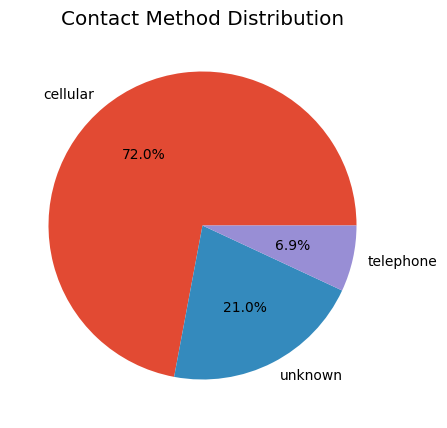

In [148]:
plt.figure(figsize=(7, 5))
df['contact'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel("")
plt.title("Contact Method Distribution")
plt.savefig("../03Images/contact_method_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [149]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

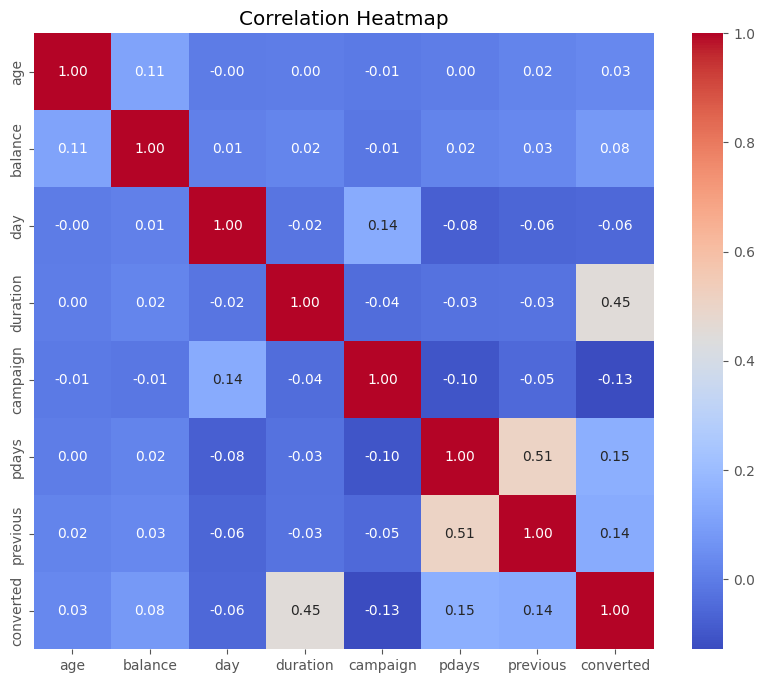

In [150]:
import seaborn as sns 

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.savefig("../03Images/correlation_heatmap.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [151]:
top_jobs = (df.groupby('job')['converted'].mean().sort_values(ascending=False).head(10)*100)
top_jobs

job
student          74.722222
retired          66.323907
unemployed       56.582633
management       50.701481
unknown          48.571429
admin.           47.301349
self-employed    46.172840
technician       46.077894
services         39.978332
housemaid        39.781022
Name: converted, dtype: float64

In [ ]:
plt.figure(figsize=(10, 5))
top_jobs.plot(kind='bar', color='royalblue')
plt.title("Top 10 Jobs by Conversion Rate")
plt.ylabel("Conversion Rate %")
plt.xticks(rotation=45)
plt.savefig("../03Images/top_10_jobs_conversion_rate.png",
            bbox_inches="tight",
            dpi=300)

plt.show()

In [ ]:
funnel = pd.DataFrame({'Stage':['Customers Contacted', 'Converted', 'Not Converted'], 'Count': [len(df), converted, not_converted]})
funnel 

In [ ]:
plt.figure(figsize=(8, 5))
plt.barh(funnel['Stage'], funnel['Count'])
plt.title("Marketing Funnel")
plt.xlabel("Customers")
plt.savefig("../03Images/marketing_funnel.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

In [ ]:
df.to_csv("Final_Marketting_Data.csv", index=False)

In [ ]:
funnel.to_csv("Marketing_Funnel.csv", index=False)

In [ ]:
job_conversion.to_csv("Job_Conversion.csv")

In [ ]:
month_conversion.to_csv("Month_Conversion.csv")